In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib as mpl
from pandas.conftest import axis

# fix errore ascii font
mpl.rcParams['font.family'] = 'sans-serif'

#### Lettura csv e creazione df aggiornato con media sentiment polarity e subjectivity

In [2]:
google_play_store = pd.read_csv('googleplaystore.csv') # 1
google_play_reviews = pd.read_csv('googleplaystore_user_reviews.csv') # 2

df = google_play_store.copy()
# creazione nuovo df con app e medie sentiment analysis
reviews = (google_play_reviews.groupby('App').agg(
    mean_sent_polarity=('Sentiment_Polarity', 'mean'),
    mean_sent_subjectivity=('Sentiment_Subjectivity', 'mean')).reset_index())

#### Cancellazione duplicati ed identificazione tipi di dato

In [3]:
df = df.drop_duplicates()
df.dtypes

App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

In [4]:
# rimozione riga con valori misti
df[df['Installs'] == 'Free']
df.drop(index=10472, inplace=True)

#### Unione dataset App e Reviews

In [5]:
df = df.merge(reviews, on='App', how='left')

#### Data processing

In [6]:
# normalizzazione valori
df = df.sort_values('Reviews', ascending=False)
df = df.drop_duplicates(subset='App', keep='first')

# sostituzione tipi
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# sostituzione tipi, simbolo 'M' e correzione valori
def convert(size):
    if pd.isna(size):
        return np.nan
    if size == 'Varies with device':
        return np.nan
    if 'M' in size:
        return float(size.replace('M', ''))
    if 'k' in size:
        return float(size.replace('k', '')) / 1024 # conversione in MB
    return np.nan
df['Size'] = df['Size'].apply(convert)

# sostituzione tipi, simbolo '+'
df['Installs'] = (df['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False))
df['Installs'] = df['Installs'].astype(float)

# sostituzione tipi, simbolo '$'
df['Price'] = (df['Price'].str.replace('$', '', regex=False))
df['Price'] = df['Price'].astype(float)

# sotituzione in formato data
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

# modifica caratteri speciali
df.loc[df['App'] == "💎 I'm rich", 'App'] = 'Diamond Im Rich'
df.loc[df['App'] == "I'm Rich/Eu sou Rico/أنا غني/我很有錢", 'App'] = "I'm Rich/Eu sou Rico"

# sostituzione '_' con spazio
df['Category'] = df['Category'].str.replace('_', ' ', regex=False)

# fix len nomi
df['App'] = df['App'].replace({
                                # grafico app con più installazioni
                                'Messenger – Text and Video Chat for Free': 'Messenger',
                                'Security Master- Antivirus, VPN, AppLock, Booster': 'Security Master',
                                'Clean Master- Space Cleaner & Antivirus': 'Clean Master',
                                'Whatsapp Messenger': 'Whatsapp',
                                # grafico app più costose nel play store
                                'Security Master - Antivirus, VPN, AppLock, Booster': 'Security Master',
                                'Human Anatomy Atlas 2018: Complete 3D Human Body': 'Human Anatomy Atlas 2018',
                                'Muscle Premium - Human Anatomy, Kinesiology, Bones': 'Muscle Premium'})

#### Tipi di dato dopo conversione

In [7]:
df.dtypes

App                                  str
Category                             str
Rating                           float64
Reviews                            int64
Size                             float64
Installs                         float64
Type                                 str
Price                            float64
Content Rating                       str
Genres                               str
Last Updated              datetime64[us]
Current Ver                          str
Android Ver                          str
mean_sent_polarity               float64
mean_sent_subjectivity           float64
dtype: object

#### Controllo null values
##### il dataset google play store contiene più app del dataset sulle reviews, esistono quindi tanti valori null a causa di mancata corrispondenza dopo unione dei due dataset

In [8]:
df.isna().sum().sort_values(ascending=False)

mean_sent_polarity        8843
mean_sent_subjectivity    8843
Rating                    1463
Size                      1227
Current Ver                  8
Android Ver                  2
Type                         1
App                          0
Category                     0
Reviews                      0
Installs                     0
Price                        0
Content Rating               0
Genres                       0
Last Updated                 0
dtype: int64

#### Per l'esplorazione delle correlazioni relative alla sentiment analysis è stata utilizzata la **sentiment polarity**, ottenuta dal dataset delle recensioni. Questa metrica rappresenta il tono medio (negativo, neutro o positivo) delle recensioni associate a ciascuna applicazione e risulta più adatta della **sentiment subjectivity** per descrivere la percezione complessiva degli utenti.

#### Sono state analizzate le seguenti relazioni:

##### - Matrice di correlazione (Spearman)
##### - Correlazione tra dimensione dell'app e sentiment polarity media
##### - Correlazione tra rating medio e sentiment polarity media
##### - Relazione tra installazioni e recensioni
##### - Categorie con il maggior numero medio di recensioni
##### - Applicazioni con il maggior numero di installazioni
##### - Distribuzione delle applicazioni per fascia d'età
##### - Categorie più presenti nel Google Play Store
##### - Confronto dei prezzi tra le principali categorie (95° percentile)
##### - Rating medio e numerosità delle categorie
##### - Confronto tra applicazioni gratuite e a pagamento
##### - Analisi della distribuzione dei prezzi e identificazione degli outlier
##### - Analisi delle applicazioni con i prezzi più elevati
##### - Ricerca di categorie con potenziale opportunità di mercato

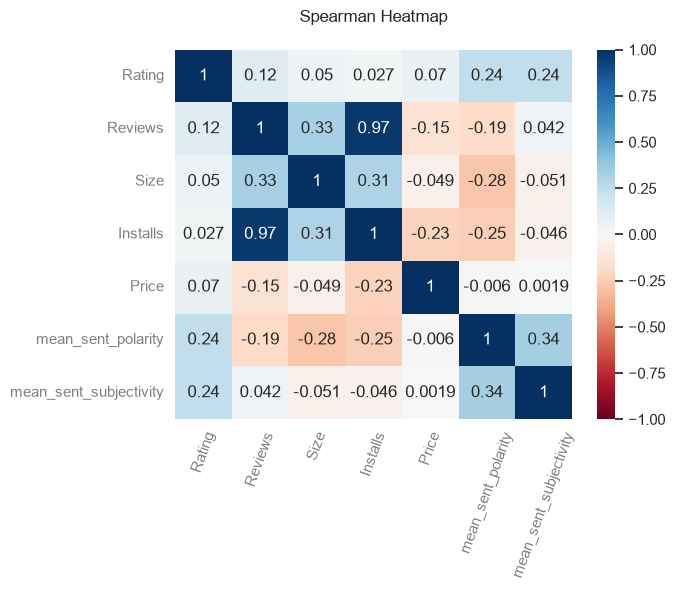

In [9]:
'''     Sono state calcolate le matrici di correlazione di Pearson e Spearman.
        Quest’ultima è stata inclusa perché il dataset contiene variabili con distribuzioni
        fortemente asimmetriche e molti outlier; consente quindi di
        individuare relazioni monotone anche quando non lineari.    '''

spearman = df.corr(numeric_only=True, method='spearman')
sns.set_theme(style='darkgrid')
sns.heatmap(
            spearman,
            annot=True,
            cmap='RdBu',
            vmin=-1, vmax=1)

plt.title('Spearman Heatmap', pad=20)
plt.tick_params(axis='x', rotation=70, pad=2, colors='gray')
plt.tick_params(axis='y', rotation=0, pad=2, colors='gray')
plt.show()

#### Correlazione negativa size - sentiment polarity
##### La heatmap mostra che esiste una leggera correlazione negativa tra la dimensione delle app e la media della polarità del sentiment osservata nella heatmap. Analizzando la distribuzione emerge che la maggior parte delle categorie si concentra tra una media di sentiment polarity di 0.15 e 0.35 mentre la dimensione media delle app è nel range 5-35 Megabyte

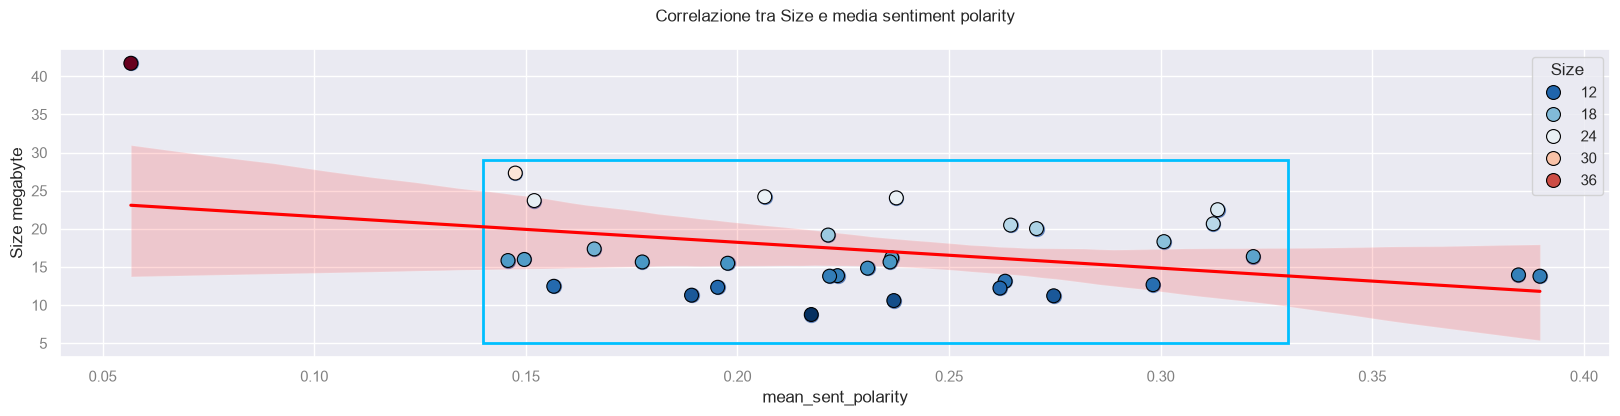

In [10]:
corr_sent_size = (df.groupby('Category')[['Size', 'mean_sent_polarity']].mean().sort_values(by='Size', ascending=False))
# subplt
fig, ax = plt.subplots(figsize=(20, 4))
sns.set_theme(style='darkgrid')

# linea regressione
sns.regplot(
            data=corr_sent_size,
            x='mean_sent_polarity',
            y='Size',
            scatter_kws={'s':100},
            line_kws={'color':'red'})

# rettangolo di selezione
rect = Rectangle((0.14, 5), 0.19, 24, edgecolor='deepskyblue', linewidth=2, fill=False)
ax.add_patch(rect)

# scatter
sns.scatterplot(
                data=corr_sent_size,
                x='mean_sent_polarity',
                y='Size',
                hue='Size',
                palette='RdBu_r',
                s=100,
                edgecolor='black')

plt.title('Correlazione tra Size e media sentiment polarity', pad=20)
plt.ylabel('Size megabyte')
plt.tick_params(axis='both', colors='gray')
plt.show()

#### Correlazione positiva rating - sentiment polarity

##### Le categorie che presentano un rating medio inferiore a circa 4,1 sono concentrate nella parte sinistra del grafico e mostrano, in generale, una sentiment polarity media più bassa. Al contrario, le categorie con rating medio superiore a circa 4,3 si concentrano nella parte destra del grafico e tendono ad avere una sentiment polarity media più elevata.
##### La retta di regressione evidenzia una moderata relazione positiva tra rating medio e sentiment polarity media: all’aumentare del rating tende infatti ad aumentare anche la polarità media delle recensioni. Sono inoltre presenti pochi outlier, distribuiti in modo relativamente uniforme, che non alterano in modo significativo il trend.

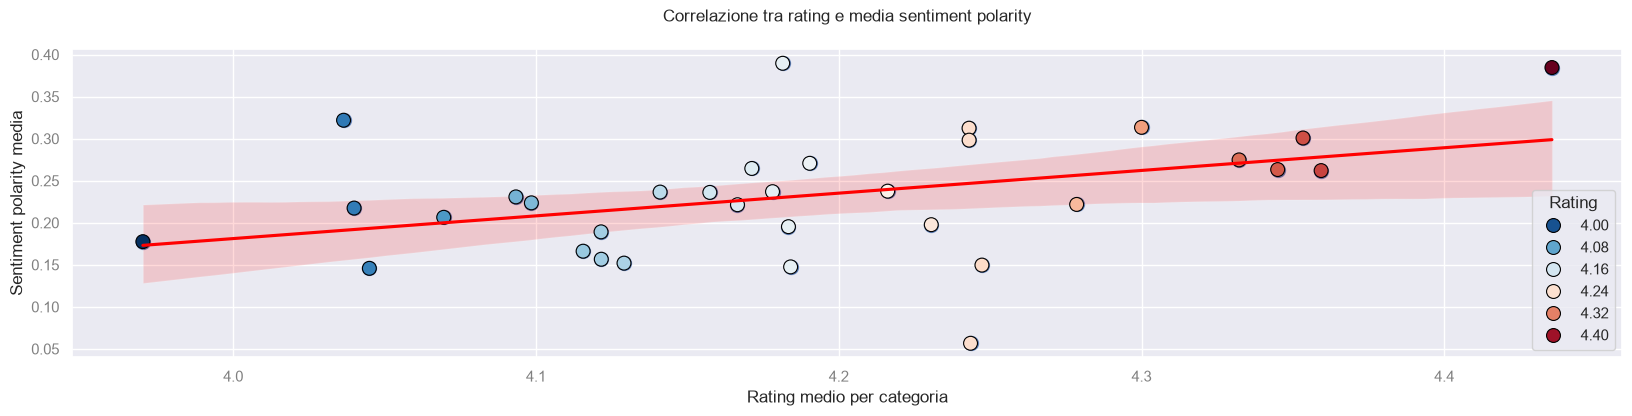

In [11]:
corr_rating_polarity = (df.groupby('Category')[['Rating', 'mean_sent_polarity']].mean().reset_index())

sns.set_theme(style='darkgrid')
plt.figure(figsize = (20,4))

sns.regplot(
            data=corr_rating_polarity,
            x='Rating',
            y='mean_sent_polarity',
            scatter_kws={'s': 100},
            line_kws={'color': 'red'})

sns.scatterplot(
                data=corr_rating_polarity,
                x='Rating',
                y='mean_sent_polarity',
                hue='Rating',
                palette='RdBu_r',
                s=100,
                edgecolor='black')

plt.title('Correlazione tra rating e media sentiment polarity', pad=20)
plt.xlabel('Rating medio per categoria')
plt.ylabel('Sentiment polarity media')
plt.tick_params(axis='both', colors='gray')
plt.show()

#### Correlazione installs-reviews
##### Dalla heatmap emerge anche che esiste una correlazione positiva medio-alta tra installs e reviews; la maggior parte delle applicazioni presenta un numero relativamente basso di recensioni, mentre esclusivamente un numero limitato di app con molte installazioni raggiunge valori molto elevati, configurandosi come outlier.

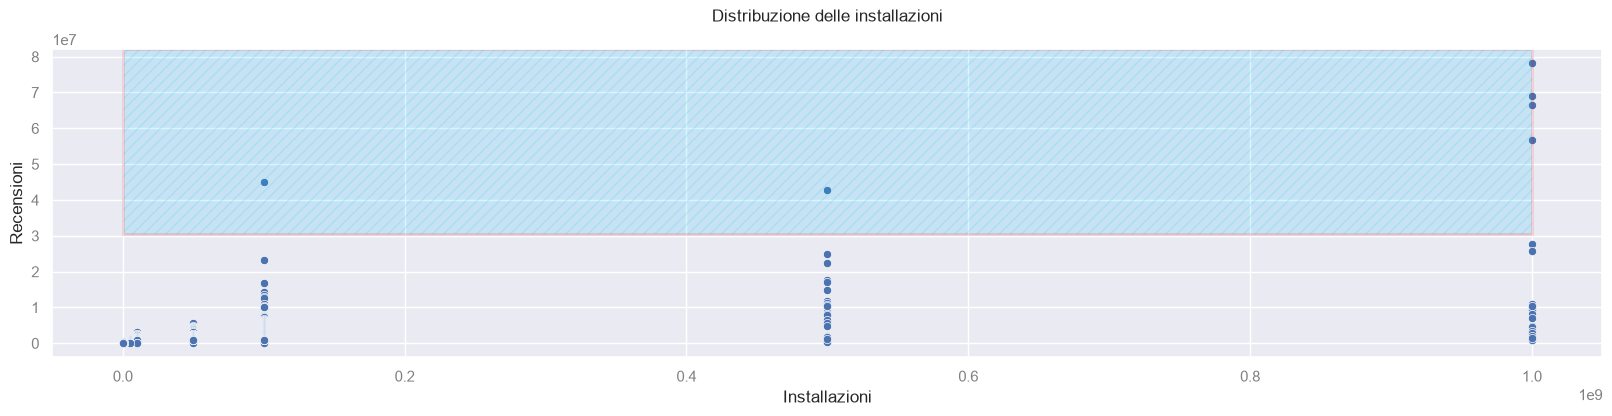

In [12]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(20, 4))

sns.scatterplot(
                data=df,
                x='Installs',
                y='Reviews')

span = plt.axvspan(
                    0,
                    1e9,
                    color='deepskyblue',
                    alpha=0.15,
                    ymin=0.4)
span.set_hatch('///')
span.set_edgecolor('red')
span.set_linewidth(2)

plt.title('Distribuzione delle installazioni', pad=20)
plt.xlabel('Installazioni')
plt.ylabel('Recensioni')
#plt.xscale('log')
#plt.yscale('log')
plt.tick_params(axis='both', colors='gray')
plt.show()

#### Categorie con media recensioni alta
##### le categorie Social, Communication, Game e Photography presentano il numero medio di recensioni più elevato. Per comprendere quali applicazioni contribuiscono maggiormente a questi risultati, sono state analizzate le app con il maggior numero di recensioni. Tra queste si distinguono Facebook, WhatsApp, Instagram, Messenger e YouTube, oltre a diversi videogiochi popolari come Subway Surfers, Clash of Clans e Clash Royale.

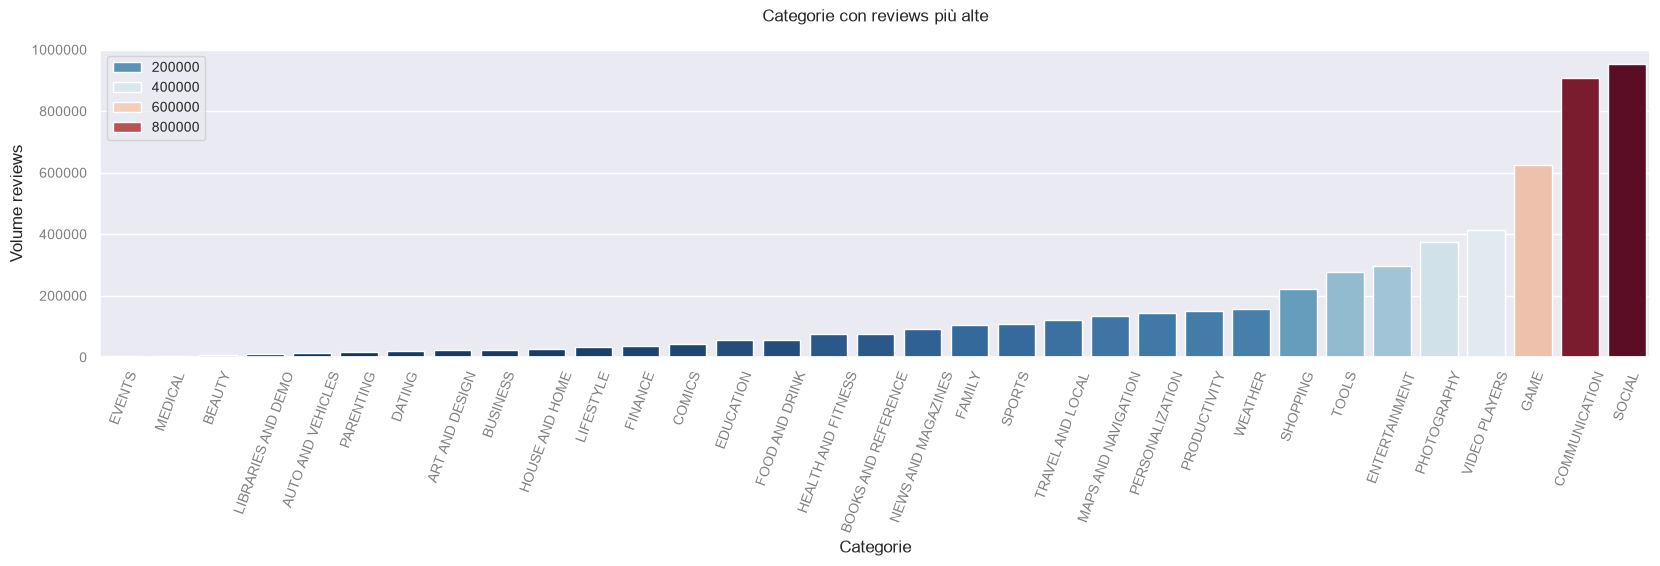

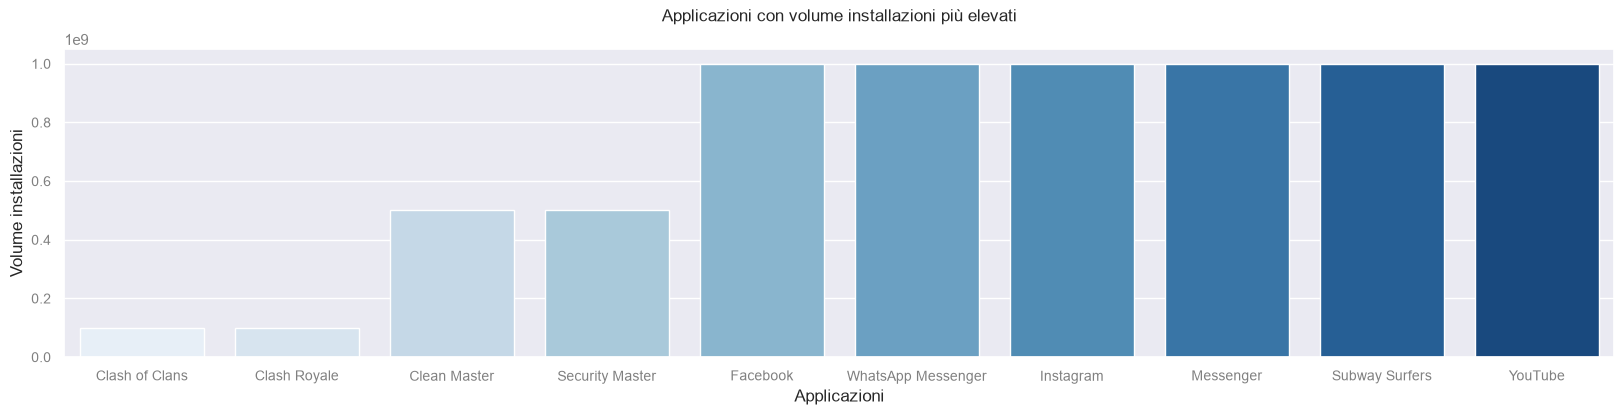

In [25]:
# classificazione categorie per reviews
classificazione = (df.groupby('Category')['Reviews'].mean().sort_values(ascending=True).reset_index())
sns.set_theme(style='darkgrid')
plt.figure(figsize = (20,4))

sns.barplot(
            data=classificazione,
            x='Category',
            y='Reviews',
            hue='Reviews',
            palette='RdBu_r')

plt.title('Categorie con reviews più alte', pad=20)
plt.legend(fontsize=10)
plt.xlabel('Categorie')
plt.ylabel('Volume reviews')
plt.xticks(rotation=70, fontsize=10)
plt.yticks(fontsize=10)
plt.ticklabel_format(style='plain', axis='y') # disattivazione notazione scientifica
plt.tick_params(axis='both', colors='gray')

# -------------------------------------------------------------------------------------------------------------------------------------------------

# classificazione app per installazioni
reviews = df.nlargest(10, 'Reviews')[['App', 'Category', 'Installs']].sort_values(by='Installs', ascending=True)
plt.figure(figsize=(20,4))

sns.barplot(
            data=reviews,
            x='App',
            y='Installs',
            hue='App',
            palette='Blues')

plt.title('Applicazioni con volume installazioni più elevati', pad=20)
plt.xlabel('Applicazioni')
plt.ylabel('Volume installazioni')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tick_params(axis='both', colors='gray')
plt.show()

#### Distribuzione delle applicazioni per fascia d'età
##### la maggior parte delle applicazioni presenti nel dataset è classificata come Everyone, risultando quindi adatta a utenti di tutte le età. La seconda categoria più rappresentata è Teen, con circa 1.000 applicazioni. Le categorie Mature 17+ ed Everyone 10+ sono meno frequenti, mentre le applicazioni destinate esclusivamente a un pubblico adulto rappresentano una quota molto ridotta del dataset.

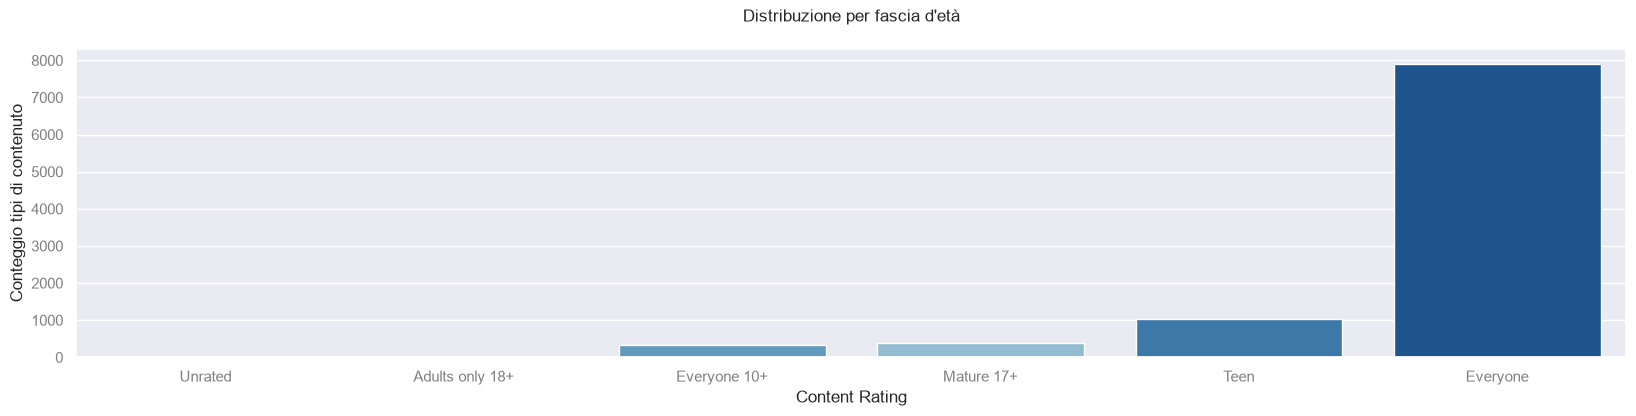

In [33]:
ordine = df['Content Rating'].value_counts().sort_values().index
sns.set_theme(style='darkgrid')
plt.figure(figsize=(20,4))

sns.countplot(
                data=df,
                x='Content Rating',
                hue='Content Rating',
                palette='Blues_r',
order=ordine)

plt.title("Distribuzione per fascia d'età", pad=20)
plt.ylabel('Conteggio tipi di contenuto')
plt.tick_params(axis='both', colors='gray')
plt.show()

#### Categorie più presenti nel play store
##### Per confrontare i prezzi tra le categorie è stato usato il 95° percentile per ridurre influenza dei valori estremi. Le categorie individuate nella top 10 risultano essere le più presenti nel play store. Considerando esclusivamente le applicazioni a pagamento, si osservano differenze nel prezzo tra le categorie, suggerendo strategie di monetizzazione differenti a seconda del settore.

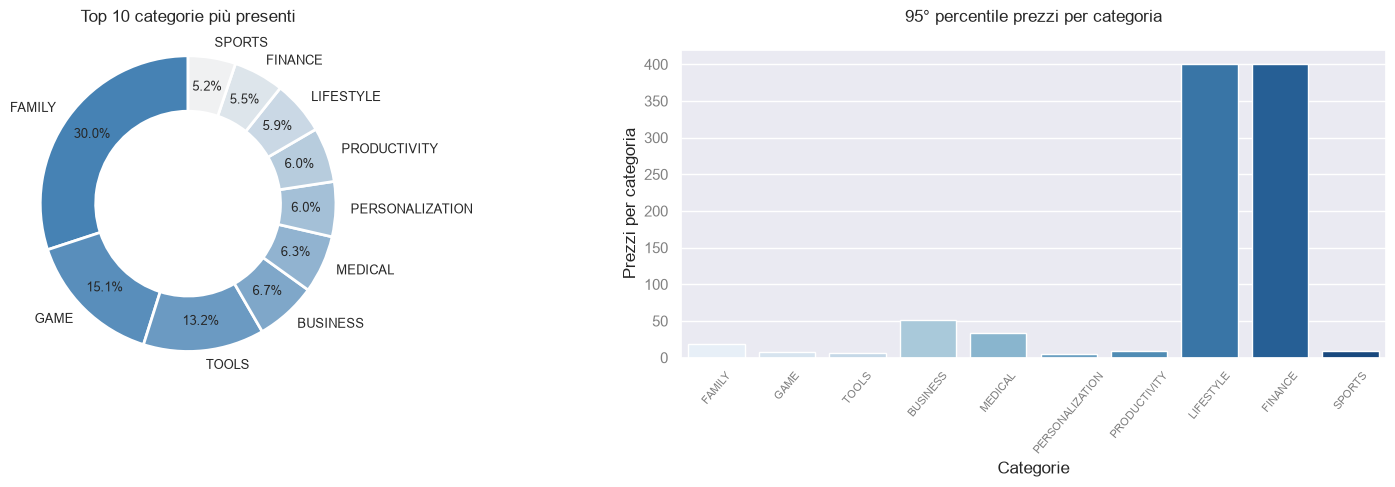

In [58]:
category_count = df['Category'].value_counts()
top_category = category_count.head(10)

# pieplot
fig, ax = plt.subplots(1, 2, figsize=(20, 4))
sns.set_theme(style='darkgrid')
colors = sns.color_palette("light:steelblue_r", len(top_category))
ax[0].set_title('Top 10 categorie più presenti', pad=20)

ax[0].pie(
            top_category.values,
            colors=colors,
            labels=top_category.index,
            autopct='%1.1f%%',
            radius=1.2,
            pctdistance=0.80,
            startangle=90,
            textprops={'fontsize': 9},
            wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 2})

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------

# barplot
tot_categorie = []
for cat in top_category.index:
    totale = df[(df['Category'] == cat) & (df['Price'] >0)]['Price'].quantile(0.95)
    tot_categorie.append(totale)

sns.barplot(
            x=top_category.index,
            y=tot_categorie,
            ax=ax[1],
            hue=top_category.index,
            palette='Blues')

ax[1].set_title('95° percentile prezzi per categoria', pad=20)
ax[1].set_ylabel('Prezzi per categoria')
ax[1].set_xlabel('Categorie')
plt.xticks(rotation=50, fontsize=8)
plt.tick_params(axis='both', colors='gray')
plt.show()

##### Le categorie più presenti nel dataset non risultano essere però quelle con il rating medio più elevato. Tuttavia, molte delle categorie meglio valutate contengono poche applicazioni, mentre altre più numerose mostrano un rating medio leggermente più basso ma più rappresentativo.

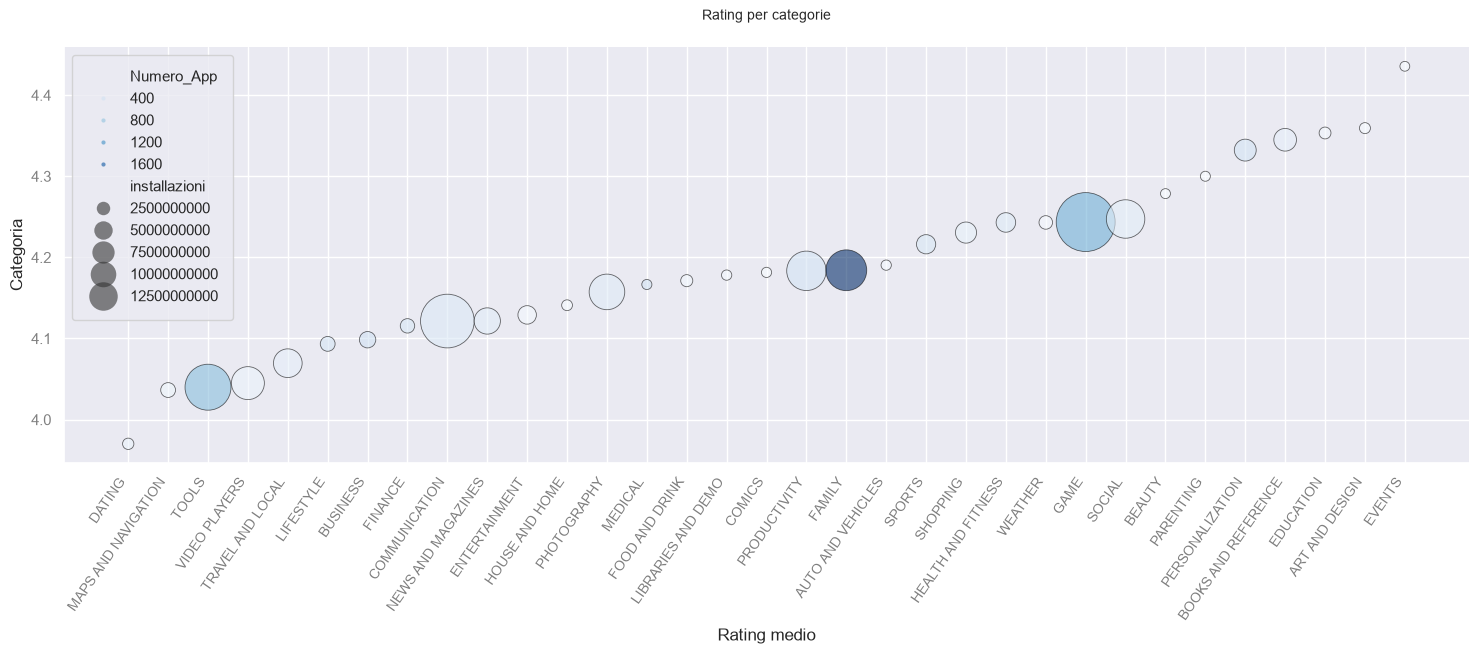

In [16]:
rating = (df.groupby('Category').agg(
        Rating_Medio=('Rating', 'mean'),
        Numero_App=('App', 'count'),
        installazioni=('Installs', 'sum')
    ).sort_values('Rating_Medio', ascending=True).reset_index())

sns.set_theme(style='darkgrid')

grafico = sns.relplot(
                        data=rating,
                        x='Category',
                        y='Rating_Medio',
                        hue='Numero_App',
                        height=5,
                        aspect=3,
                        alpha=0.6,
                        edgecolor='black',
                        palette='Blues',
                        size='installazioni',
                        sizes=(50, 1800))

grafico.legend.remove()
plt.title('Rating per categorie', loc='center', fontsize=10, pad=20)
plt.xlabel('Rating medio')
plt.ylabel('Categoria')
plt.legend(markerscale=0.5, borderpad=1)
plt.xticks(rotation=55, ha='right', fontsize=10)
plt.tick_params(axis='both', colors='gray')
plt.show()

#### Analisi apps Free vs paid
##### Le applicazioni a pagamento con maggiori volumi sono distribuite nelle categorie: family, game, tools, medical e personalization; insieme vanno a comporre solamente il 7,8% di google play store. Le app gratuite sono invece il 92.1%.

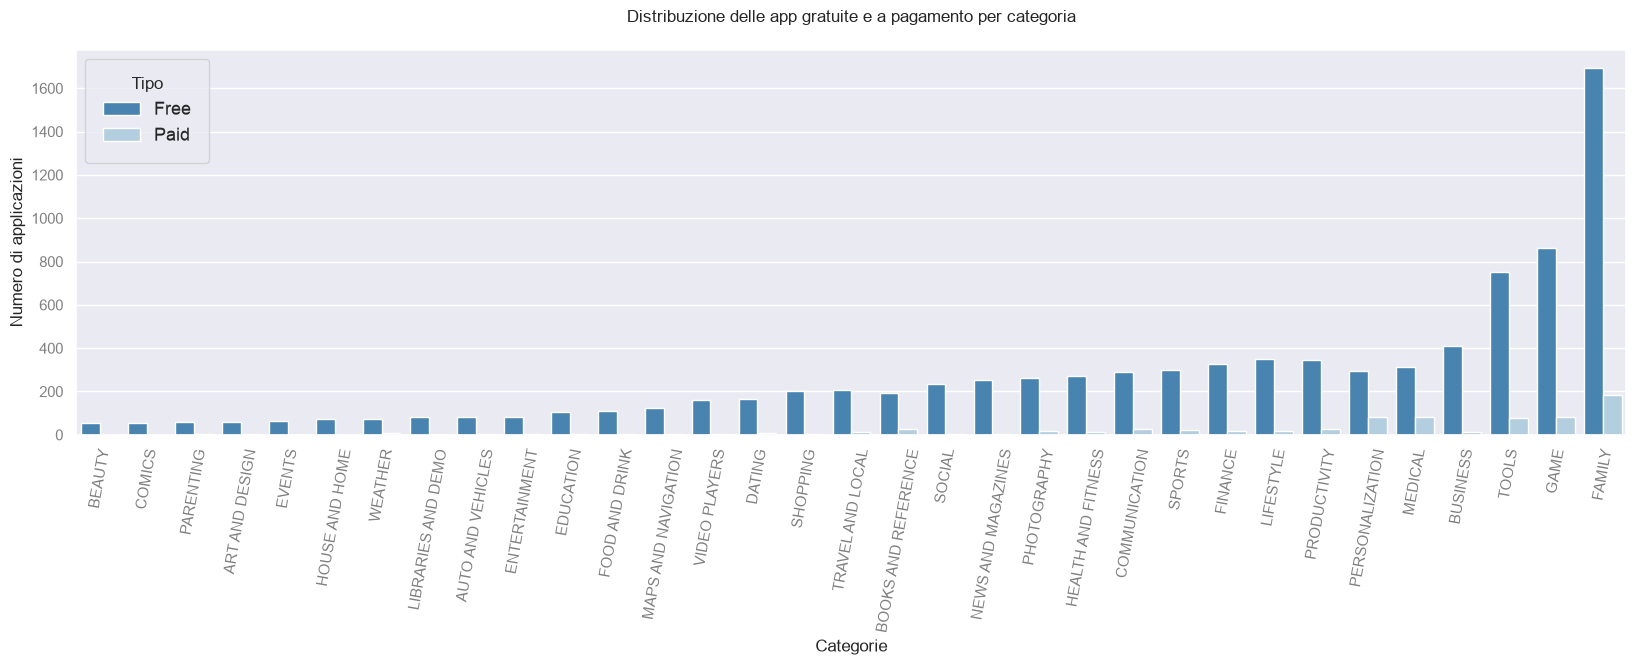

In [59]:
count_app = (df.groupby(['Category', 'Type']).size().reset_index(name='Count'))
ordine = (count_app.groupby('Category')['Count'].sum().sort_values(ascending=True).index)

sns.set_theme(style='darkgrid')
plt.figure(figsize=(20,5))

sns.barplot(
            data=count_app,
            x='Category',
            y='Count',
            hue='Type',
            palette='Blues_r',
            order=ordine)

plt.title('Distribuzione delle app gratuite e a pagamento per categoria', pad=20)
plt.xlabel('Categorie')
plt.ylabel('Numero di applicazioni')
plt.xticks(rotation=80)
plt.tick_params(axis='both', colors='gray')
plt.legend(title='Tipo', markerscale=1, borderpad=1, fontsize=13)

plt.show()

#### Ricerca concentrazione app per fascia di prezzo
##### E' stata rilevata la fascia di prezzo delle app sotto il 25 euro con il 95° percentile, evitando la scelta di una soglia arbitraria restando relativamente vicino alla media dei prezzi.

In [18]:
# ricerca fascia di prezzo
q95 = df[df['Price'] > 0]['Price'].quantile(0.95)
print('95° percentile: ', q95)

# ricerca media dei prezzi
media_prezzi = (df[df['Price']>0]['Price'].mean())
print('Media prezzi: ', media_prezzi)

95° percentile:  24.99
Media prezzi:  14.045145502645504


##### Le applicazioni a pagamento si concentrano principalmente nella fascia di prezzo compresa tra 0 e circa 25 euro. Al di sopra del 95° percentile sono presenti pochi outlier, con prezzi compresi tra 25 e 400 euro, evidenziati nel grafico dalla banda blu.

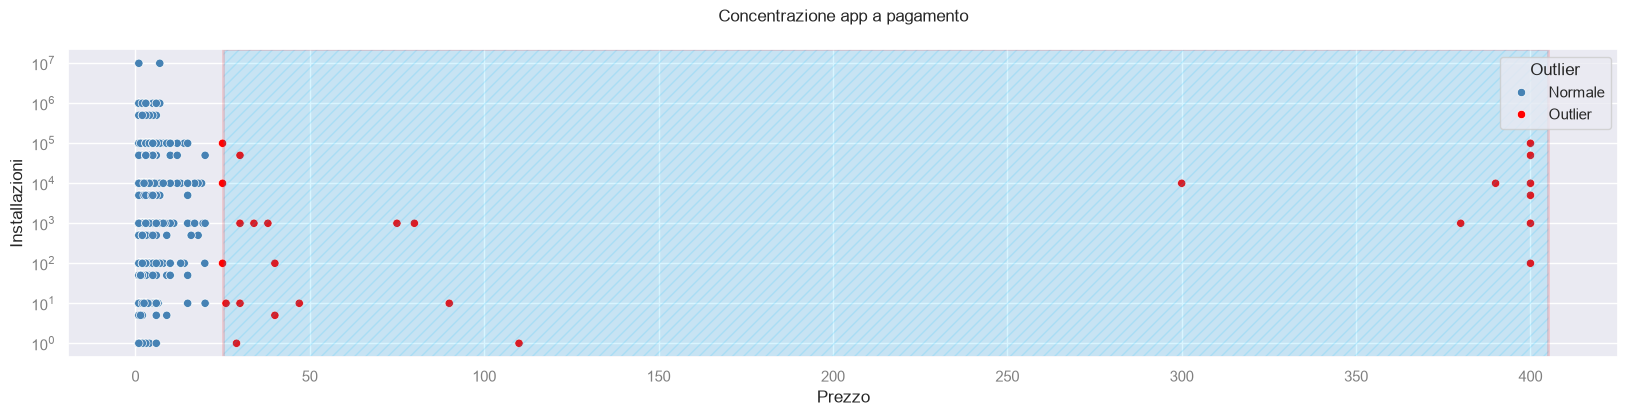

In [19]:
q95 = df[df['Price'] > 0]['Price'].quantile(0.95)
otlr= df[df['Price'] > 0].assign(Outlier=lambda x: np.where(x['Price'] >= q95, 'Outlier', 'Normale'))

sns.set_theme(style='darkgrid')
plt.figure(figsize=(20, 4))

sns.scatterplot(
                data=otlr,
                x='Price',
                y='Installs',
                hue='Outlier',
                palette={'Outlier': 'red',
                         'Normale':'steelblue'})

# fascia di prezzo 25-400 €
span = plt.axvspan(
                    24.99,
                    405,
                    color='deepskyblue',
                    alpha=0.15)
span.set_hatch('///')
span.set_edgecolor('red')
span.set_linewidth(2)

plt.title('Concentrazione app a pagamento', pad=20)
plt.xlabel('Prezzo')
plt.ylabel('Installazioni')
plt.yscale('log')
plt.tick_params(axis='both', colors='gray')
plt.show()

##### Le app con i prezzi più elevati appartengono prevalentemente alla serie “I’m Rich”, una categoria di app simboliche o dimostrative, prive di funzionalità particolarmente rilevanti e commercializzate a prezzi estremamente elevati. Tra queste spicca “I’m Rich - Trump Edition”, che rappresenta l’applicazione più costosa del dataset con un prezzo di 400 dollari.

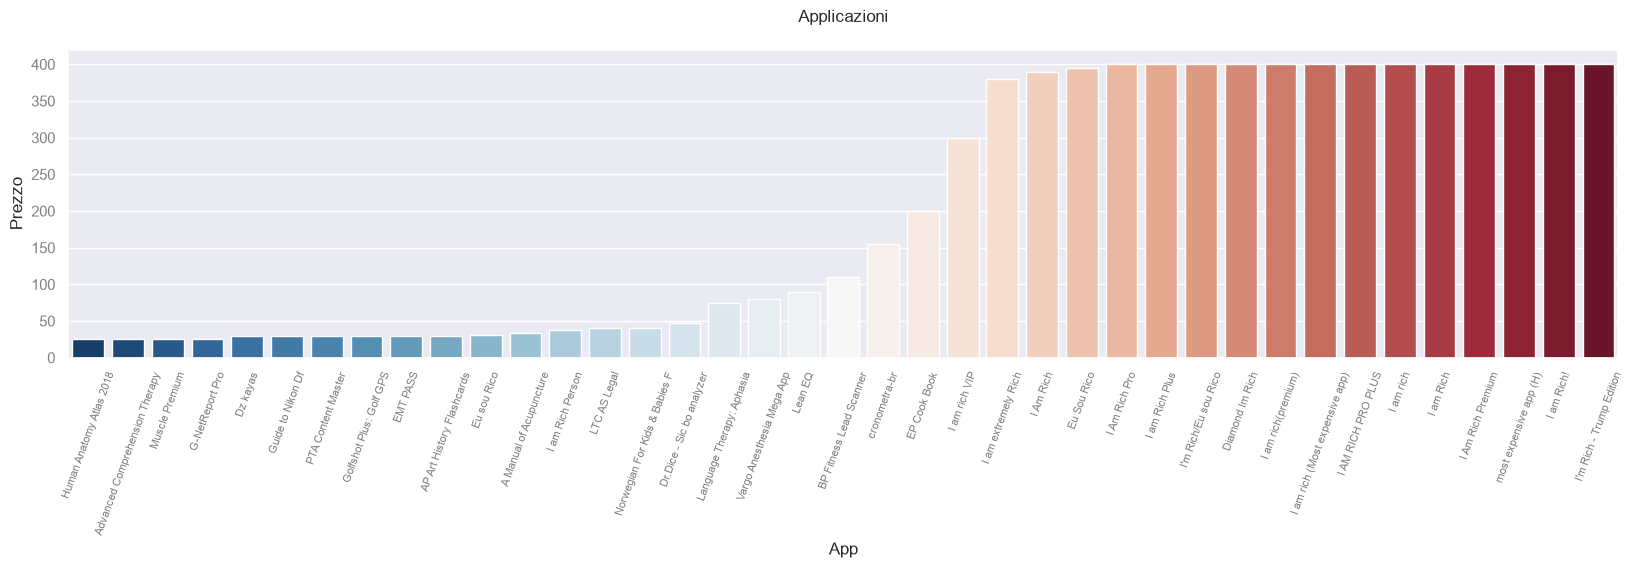

In [20]:
# ricerca prezzo medio e filtraggio solo su app con prezzo >= alla media
mean_p = (df[df['Price'] > 0]['Price'].quantile(0.95))
mean_price = (df[df['Price'] >= mean_p][['App', 'Price']].sort_values(by='Price', ascending=True).reset_index())

sns.set_theme(style='darkgrid')
plt.figure(figsize=(20,4))
sns.barplot(
            data=mean_price,
            x='App',
            y='Price',
            palette='RdBu_r',
            hue='App')

plt.title('Applicazioni', pad=20)
plt.xlabel('App')
plt.ylabel('Prezzo')
plt.xticks(rotation=70, fontsize=8)
plt.tick_params(axis='both', colors='gray')
plt.show()

In [21]:
df['Type'].value_counts(normalize=True).mul(100).round(92)

Type
Free    92.172292
Paid     7.827708
Name: proportion, dtype: float64

In [22]:
df.nlargest(1, 'Price')[['App', 'Price']].sort_values(by='Price', ascending=False)

,App,Price
3913,I'm Rich - Trump Edition,400.0


#### Ricerca posizione di mercato

##### Per la ricerca di un mercato potenziale i dati sono stati filtrati in base alle categorie sotto il 75° percentile dove al di sotto si trovano categorie non dominate da aziende con forte posizionamento e mercati saturi. Sono state incluse tutte le categorie etichettate come "Everyone" e "Teen" essendo la parte dominante del play store, avendo così modo di evitare nicchie.
##### Succesivamente sono state filtrate con 25° percentile le categorie con un basso volume di installazioni e quindi con poco mercato, sono state mantenute quelle con sentiment analysis positiva con valori di almeno 0.2

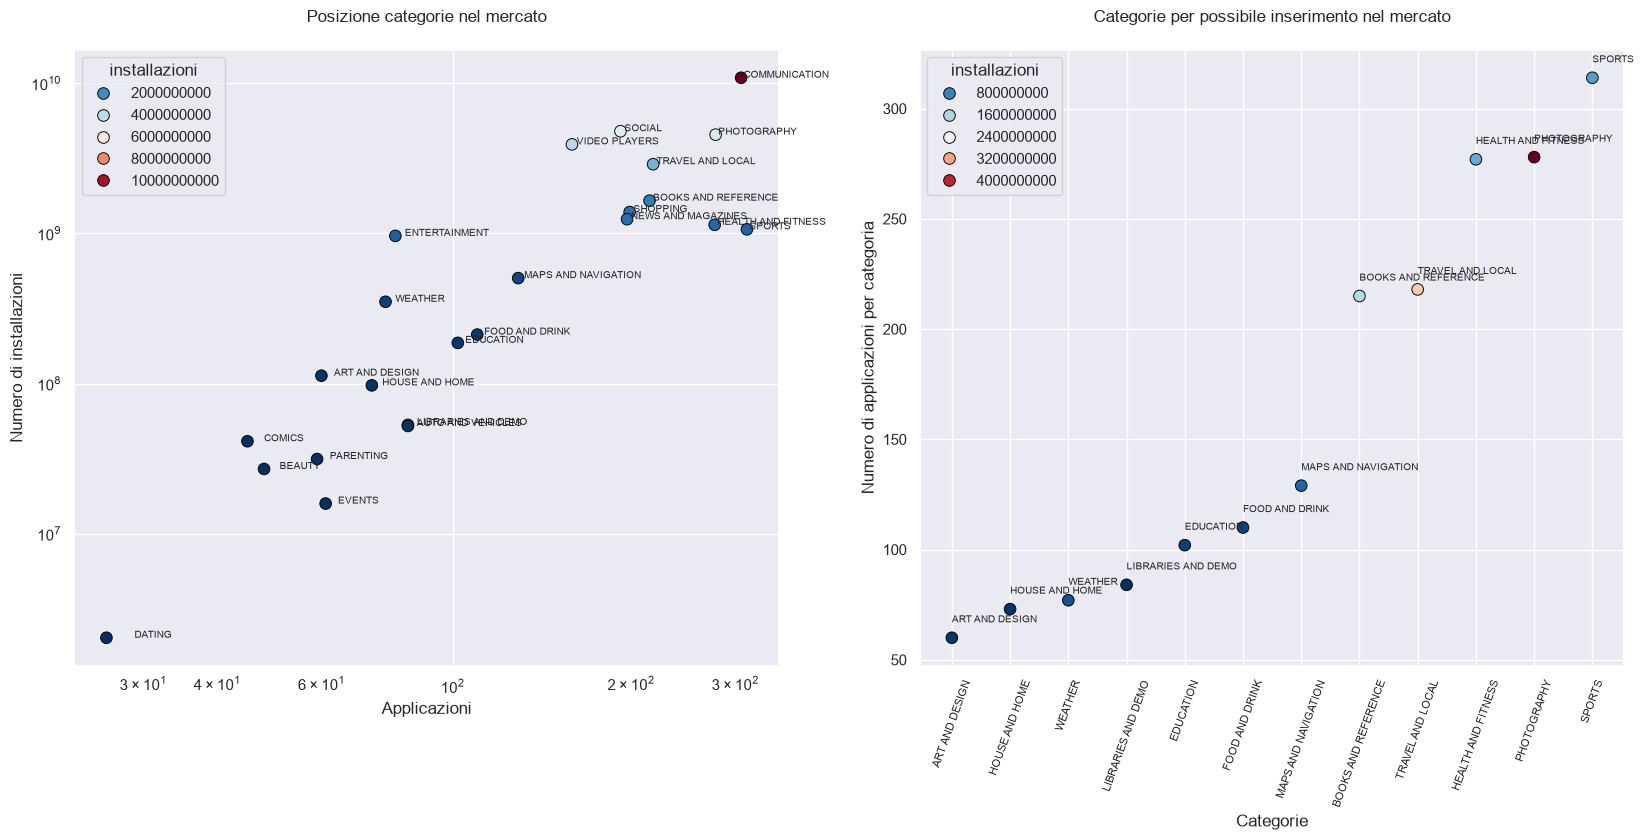

In [23]:
mkt = (df[
        (df['Content Rating']=='Everyone') | (df['Content Rating']=='Teen')
        ].groupby('Category').agg(
            tot_app=('App', 'count'),
            installazioni=('Installs', 'sum'),
            sentiment=('mean_sent_polarity', 'mean')
        ).sort_values('installazioni', ascending=False).reset_index())

q75 = mkt['tot_app'].quantile(0.75)
mkt = mkt[mkt['tot_app'] < q75]

#   --- SCATTER 1
sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(1,2, figsize=(20,8))
ax[0].set_title('Posizione categorie nel mercato', pad=20)
ax[0].set_xlabel('Applicazioni')
ax[0].set_ylabel('Numero di installazioni')
ax[0].set_xscale('log')
ax[0].set_yscale('log')

sctr = sns.scatterplot(
                        data=mkt,
                        x='tot_app',
                        y='installazioni',
                        s=70,
                        edgecolor='black',
                        hue='installazioni',
                        palette='RdBu_r',
                        ax=ax[0])

for _, row in mkt.iterrows():
    sctr.text(
                row['tot_app'] + 3,
                row['installazioni'],
                row['Category'],
                fontsize=7,
                ha='left')


# --------------------------------------------------------------------------------------------------------------------------------------------------------------


#   --- SCATTER 2
q25 = mkt['installazioni'].quantile(0.25)
mercato = (mkt[(mkt['tot_app'] <= q75) & (mkt['installazioni'] > q25) & (mkt['sentiment'] > 0.2)].sort_values(by='tot_app',ascending=True))

plt.xticks(rotation=70, fontsize=8)
ax[1].set_title('Categorie per possibile inserimento nel mercato', pad=20)
ax[1].set_xlabel('Categorie')
ax[1].set_ylabel('Numero di applicazioni per categoria')
#ax[1].set_xscale('log')
#ax[1].set_yscale('log')

mkt_filter = (sns.scatterplot(
                                data=mercato,
                                x='Category',
                                y='tot_app',
                                hue='installazioni',
                                palette='RdBu_r',
                                s=70,
                                edgecolors='black',
                                ax=ax[1]))

for _, row in mercato.iterrows():
        ax[1].text(
                    row['Category'],
                    row['tot_app'] + 7,
                    row['Category'],
                    fontsize=7,
                    ha='left')

plt.show()

##### Le categorie individuate presentano un buon equilibrio tra il numero di installazioni ed app presenti nella categoria andando cosi a ridurre il livello di concorrenza; inoltre presentano anche livelli di sentiment positivo. In particolare: Art & Design, House & Home, Weather, Libraries & Demo ed Education si configurano come potenziale opportunità per il lancio di nuove applicazioni rispetto alle rimanenti, avendo un numero inferiore di app presenti nella categoria.

In [24]:
mercato[['Category', 'tot_app']].head(10)

,Category,tot_app
23,ART AND DESIGN,60
24,HOUSE AND HOME,73
20,WEATHER,77
25,LIBRARIES AND DEMO,84
22,EDUCATION,102
21,FOOD AND DRINK,110
17,MAPS AND NAVIGATION,129
9,BOOKS AND REFERENCE,215
8,TRAVEL AND LOCAL,218
13,HEALTH AND FITNESS,277


#### Conclusioni
##### L’analisi del Google Play Store mostra un mercato fortemente concentrato nelle categorie Family, Game e Tools, caratterizzate da un’elevata concorrenza. Le applicazioni a pagamento presentano prevalentemente prezzi inferiori ai 25 dollari, mentre valori superiori costituiscono casi eccezionali. L’integrazione delle informazioni relative a installazioni, numero di applicazioni e sentiment ha consentito di individuare alcune categorie che presentano un equilibrio favorevole tra domanda, competizione e soddisfazione degli utenti, rappresentando potenziali opportunità per il lancio di nuove applicazioni.